# 실습 4: 센서 하나로 이상 구간 찾기
- 상황: 3라인 계측 기록에서 평소와 다르게 튄 구간을 찾아본다
- 목표: 관리선을 긋고 벗어난 구간을 잡는다

## Step 1. 불러오기와 기본 확인

In [1]:
import pandas as pd

df = pd.read_csv("../../data/04_secom.csv")

# 1. 전체 행 수와 열 수
print("shape (행, 열):", df.shape)

# 2. result 열의 값 종류별 건수와 비율
print("\nresult 값별 건수:")
print(df["result"].value_counts())
print("\nresult 값별 비율:")
print(df["result"].value_counts(normalize=True))

# 3. head()
df.head()


shape (행, 열): (1567, 592)

result 값별 건수:
result
양품    1463
불량     104
Name: count, dtype: int64

result 값별 비율:
result
양품    0.933631
불량    0.066369
Name: proportion, dtype: float64


,measured_at,sensor_001,sensor_002,sensor_003,sensor_004,sensor_005,sensor_006,sensor_007,sensor_008,sensor_009,...,sensor_582,sensor_583,sensor_584,sensor_585,sensor_586,sensor_587,sensor_588,sensor_589,sensor_590,result
0,19/07/2008 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,...,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,양품
1,19/07/2008 12:32:00,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,양품
2,19/07/2008 13:17:00,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,불량
3,19/07/2008 14:43:00,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,...,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,양품
4,19/07/2008 15:22:00,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,...,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,양품


## Step 2. 관리도라는 말부터

### 용어 풀이 - 관리도 주변

| 말 | 뜻 |
|---|---|
| 관리도 | 값을 시간 순서대로 그려두고, 평소 범위를 벗어나는 순간을 잡는 그림 |
| 관리선 | 평소 범위의 경계선. 위쪽 선을 관리 상한, 아래쪽 선을 관리 하한이라 부른다 |
| 평균 | 값들을 다 더해 개수로 나눈 것. 관리도의 한가운데 선이 된다 |
| 표준편차 | 값들이 평균에서 얼마나 흩어져 있는지. 작으면 몰려 있고 크면 넓게 퍼져 있다 |
| 이상 구간 | 관리선을 벗어난 구간. 벗어났다는 것이지 곧 불량이라는 뜻은 아니다 |
| result (판정) | 검사에서 붙은 양품 또는 불량. 공정이 다 끝난 뒤에 붙는다 |
| SPC | 이런 방식으로 공정을 감시하는 것을 통틀어 부르는 말 |

## Step 3. 센서 하나 고르기

In [2]:
sensor_cols = [c for c in df.columns if c.startswith("sensor_")]

# 빈칸(NaN) 없고, 값이 하나로 고정되지 않은(nunique > 1) 센서 열만 추리기
valid_cols = [c for c in sensor_cols if df[c].isna().sum() == 0 and df[c].nunique() > 1]
print("조건에 맞는 센서 열 개수:", len(valid_cols))

picked = valid_cols[:5]

rows = []
for c in picked:
    vmin = df[c].min()
    vmax = df[c].max()
    nuniq = df[c].nunique()

    if nuniq < 10:
        judge = "정해 넣은 값에 가까움"
    elif nuniq >= 20:
        judge = "재고 있는 값에 가까움"
    else:
        judge = "애매함 (10~19가지, 확실하지 않음)"

    if vmax >= 1000:
        digit_note = "큰 수로 세는 값에 가까움 (추정)"
    elif vmax >= 10:
        digit_note = "온도처럼 큰 눈금의 값에 가까움 (추정)"
    elif vmax >= 1:
        digit_note = "비율처럼 보이는 값에 가까움 (추정)"
    else:
        digit_note = "아주 미세한 값에 가까움 (추정)"

    rows.append({
        "센서 이름": c,
        "최소": vmin,
        "최대": vmax,
        "값 종류 수": nuniq,
        "판정(종류 수 기준)": judge,
        "자릿수로 본 성격(추정, 확실하지 않음)": digit_note,
    })

result_df = pd.DataFrame(rows)
result_df


조건에 맞는 센서 열 개수: 52


,센서 이름,최소,최대,값 종류 수,판정(종류 수 기준),"자릿수로 본 성격(추정, 확실하지 않음)"
0,sensor_021,1.1797,1.4534,552,재고 있는 값에 가까움,비율처럼 보이는 값에 가까움 (추정)
1,sensor_087,2.2425,2.5555,472,재고 있는 값에 가까움,비율처럼 보이는 값에 가까움 (추정)
2,sensor_088,0.7749,0.9935,249,재고 있는 값에 가까움,아주 미세한 값에 가까움 (추정)
3,sensor_089,1627.4714,2105.1823,973,재고 있는 값에 가까움,큰 수로 세는 값에 가까움 (추정)
4,sensor_114,0.8534,0.9763,468,재고 있는 값에 가까움,아주 미세한 값에 가까움 (추정)


[내가 고른 열]<br>
고른 열 : [sensor_089]<br>
값 범위 : [1627.47] ~ [2105.18]   값 종류 : [973]가지<br>
값 종류가 [많으니] 이 열은 [재고 있는 값]에 가깝다<br>
AI가 본 성격 : [세 자리 이상 — 큰 수로 세는 값]

## Step 4. 평소 범위를 정하기
평균에서 표준편차 3배만큼 위아래로 관리선을 긋는다.

In [3]:
# 앞에서 고른 센서 이름을 넣는다 (본인이 고른 것으로 바꾸세요)
센서 = "sensor_089"

# 평균 — 이 센서 값들의 한가운데
평균 = df[센서].mean()

# 표준편차 — 값들이 평균에서 얼마나 흩어져 있는지
표준편차 = df[센서].std()

# 관리 상한 / 하한 — 평균에서 표준편차 3배만큼 위아래
위선 = 평균 + 3 * 표준편차
아래선 = 평균 - 3 * 표준편차

# round(값, 2) — 소수점 둘째 자리까지만 보여준다
print("평균:", round(평균, 2))
print("관리 상한:", round(위선, 2))
print("관리 하한:", round(아래선, 2))

평균: 1807.82
관리 상한: 1968.43
관리 하한: 1647.2


## Step 5. 관리도 그리기

### 문법 노트 - 그림 그리기 첫걸음

| 쓴 것 | 하는 일 |
|---|---|
| plt.plot(값들) | 값을 순서대로 이어 선으로 그린다 |
| plt.axhline(높이) | 그 높이에 가로선 하나를 긋는다. 관리선이 바로 이것 |
| color="red" | 선 색을 정한다 |
| linestyle="--" | 선을 점선으로 만든다 (실선인 평균선과 구분되게) |
| plt.show() | 지금까지 얹은 것들을 한 장으로 띄운다 |
| round(값, 2) | 소수점 둘째 자리까지만 남긴다 |

**한 장의 도화지에 하나씩 얹는 방식이다.**<br>
선을 그리고, 그 위에 가로선을 세 개 얹고, 마지막에 show로 완성해서 보여준다.<br>
그래서 순서대로 쭉 쓰면 된다.

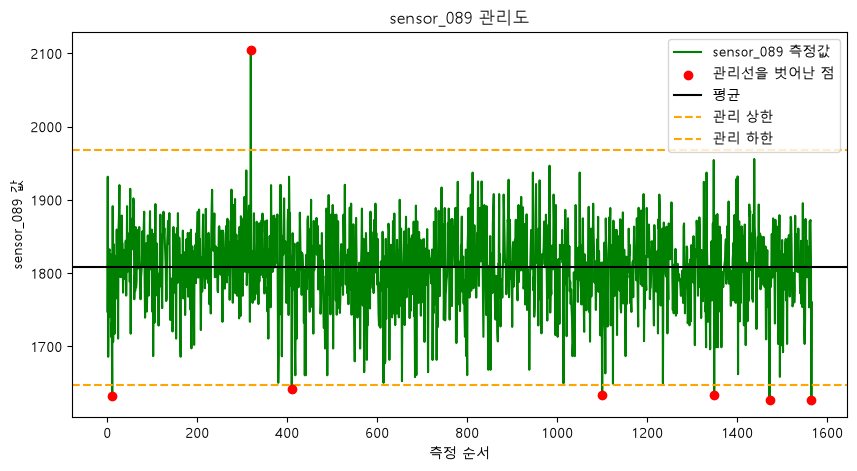

In [4]:
# 그림 그리는 도구를 plt라는 짧은 이름으로 불러온다
import matplotlib.pyplot as plt
import os

# 한글이 깨지지 않도록 한글 지원 폰트로 지정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 관리선을 벗어난 점 찾기
벗어난 = (df[센서] > 위선) | (df[센서] < 아래선)

plt.figure(figsize=(10, 5))

# 센서 값을 측정 순서대로 초록색 선으로 그린다
plt.plot(df[센서], color="green", label=f"{센서} 측정값")

# 관리선을 벗어난 점만 다른 색(빨강)으로 표시
plt.scatter(
    df.index[벗어난], df[센서][벗어난],
    color="red", zorder=5, label="관리선을 벗어난 점"
)

# axhline — 가로로 쭉 뻗는 선 하나를 긋는다 (h는 horizontal, 수평)
plt.axhline(평균, color="black", linestyle="-", label="평균")
plt.axhline(위선, color="orange", linestyle="--", label="관리 상한")
plt.axhline(아래선, color="orange", linestyle="--", label="관리 하한")

# 제목과 축 이름
plt.title(f"{센서} 관리도")
plt.xlabel("측정 순서")
plt.ylabel(f"{센서} 값")

# 각 선이 무엇인지 알아보도록 이름표(범례) 표시
plt.legend()

# 이 노트북이 있는 폴더 안에 results 폴더를 만들고 그림 저장
os.makedirs("results", exist_ok=True)
plt.savefig(f"results/{센서}_control_chart.png", dpi=150, bbox_inches="tight")

# 그림을 화면에 띄운다
plt.show()


선을 넘은 점 : [7]개<br>
그중 관리 상한을 넘은 점 : [1]개   관리 하한 아래로 내려간 점 : [6]개

## Step 6. 선을 넘은 것이 불량이었나

In [5]:
# sensor_089가 관리 상한 또는 하한을 벗어난 행만 고르기
벗어난 = (df[센서] > 위선) | (df[센서] < 아래선)
벗어난_행 = df[벗어난]

print("관리선을 벗어난 행 개수:", len(벗어난_행))
print("\n벗어난 행의 result 값별 건수:")
print(벗어난_행["result"].value_counts())
print("\n벗어난 행의 result 값별 비율:")
print(벗어난_행["result"].value_counts(normalize=True))

# 전체 불량 비율과 비교하는 표
전체_불량비율 = (df["result"] == "불량").mean()
벗어난_불량비율 = (벗어난_행["result"] == "불량").mean()

비교표 = pd.DataFrame({
    "구분": ["전체", f"{센서} 관리선 벗어난 행"],
    "행 수": [len(df), len(벗어난_행)],
    "불량 수": [(df["result"] == "불량").sum(), (벗어난_행["result"] == "불량").sum()],
    "불량 비율": [전체_불량비율, 벗어난_불량비율],
})
비교표


관리선을 벗어난 행 개수: 7

벗어난 행의 result 값별 건수:
result
양품    6
불량    1
Name: count, dtype: int64

벗어난 행의 result 값별 비율:
result
양품    0.857143
불량    0.142857
Name: proportion, dtype: float64


,구분,행 수,불량 수,불량 비율
0,전체,1567,104,0.066369
1,sensor_089 관리선 벗어난 행,7,1,0.142857


## Step 7. 그런데 590개는요?

센서 1개를 확인하는 데 실행한 코드 칸과 AI 요청 : [5]번<br>
590개를 다 하려면? -> 590 x [5] = [2950]번<br>
게다가 그림 590장을 하나씩 눈으로 봐야 한다.

---
## 직접 해보기 (도전) - 선을 좁히면 어떻게 될까

- 상황: 관리선을 표준편차 3배로 그었다. 이건 관행일 뿐 정답이 아니다
- 할 일: 같은 센서에 2배로 다시 그어 3배일 때와 숫자를 비교한다
- 결과물: 네 줄짜리 비교표 1개

In [6]:
전체_불량비율 = (df["result"] == "불량").mean()

def 관리선_분석(배수):
    위 = 평균 + 배수 * 표준편차
    아래 = 평균 - 배수 * 표준편차
    벗어난 = (df[센서] > 위) | (df[센서] < 아래)
    벗어난_행 = df[벗어난]

    벗어난_행수 = len(벗어난_행)
    불량_수 = int((벗어난_행["result"] == "불량").sum())
    불량_비율 = (불량_수 / 벗어난_행수) if 벗어난_행수 > 0 else None

    if 불량_비율 is None:
        비교 = "해당 없음 (벗어난 행 없음)"
    else:
        비교 = f"전체의 {round(불량_비율 / 전체_불량비율, 2)}배"

    return {
        "기준": f"표준편차 {배수}배",
        "관리 상한": round(위, 2),
        "관리 하한": round(아래, 2),
        "벗어난 행 수": 벗어난_행수,
        "그중 불량 수": 불량_수,
        "불량 비율(%)": round(불량_비율 * 100, 2) if 불량_비율 is not None else None,
        "전체 불량 비율(6.6%) 대비": 비교,
    }

기준A = 관리선_분석(3)
기준B = 관리선_분석(2)

비교표_AB = pd.DataFrame([기준A, 기준B])
비교표_AB


,기준,관리 상한,관리 하한,벗어난 행 수,그중 불량 수,불량 비율(%),전체 불량 비율(6.6%) 대비
0,표준편차 3배,1968.43,1647.20,7,1,14.29,전체의 2.15배
1,표준편차 2배,1914.89,1700.74,81,5,6.17,전체의 0.93배


### 관리선 2배 vs 3배

| 항목 | 3배 | 2배 |
|---|---|---|
| 관리 상한 | [1968.4] | [1914.9] |
| 관리 하한 | [1647.2] | [1700.7] |
| 벗어난 행 수 | [7] | [81] |
| 그 행들의 불량 비율 (%) | [14.3] | [6.2] |